In [22]:
import sys
sys.path.append("..//")

import aqua
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.stimulus import *
from aqua.plotting_functions import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import pickle
import random

from functions import *
from CF import read_conf

Index(['e', 'f', 'tau', 'autapse current', 'autapse delay', 'I_h', 'F_instant',
       'F_steady', 'num_frequencies', 'entropy'],
      dtype='object')
[  0.           1.25628141   2.51256281   3.76884422   5.02512563
   6.28140704   7.53768844   8.79396985  10.05025126  11.30653266
  12.56281407  13.81909548  15.07537688  16.33165829  17.5879397
  18.84422111  20.10050251  21.35678392  22.61306533  23.86934673
  25.12562814  26.38190955  27.63819095  28.89447236  30.15075377
  31.40703518  32.66331658  33.91959799  35.1758794   36.4321608
  37.68844221  38.94472362  40.20100503  41.45728643  42.71356784
  43.96984925  45.22613065  46.48241206  47.73869347  48.99497487
  50.25125628  51.50753769  52.7638191   54.0201005   55.27638191
  56.53266332  57.78894472  59.04522613  60.30150754  61.55778894
  62.81407035  64.07035176  65.32663317  66.58291457  67.83919598
  69.09547739  70.35175879  71.6080402   72.86432161  74.12060302
  75.37688442  76.63316583  77.88944724  79.14572864  80.4

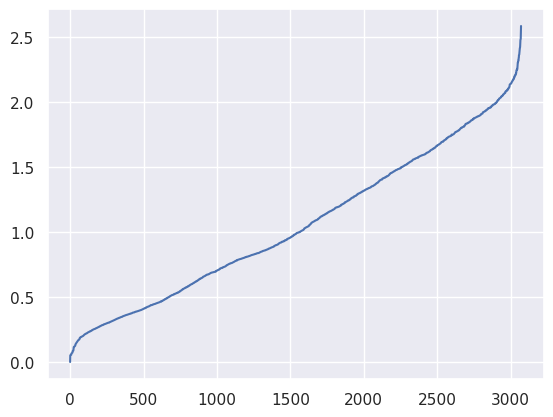

In [23]:
# import data
SAVE = False
neuron = "RS_intHD_uniform"
out_dir = f".//{neuron}//"

filename = f"{neuron}_GAIN.pickle"
with open(out_dir + filename, 'rb') as file:
    df = pickle.load(file)

# import spikes
filename = f"{neuron}_SPIKES.pickle"
with open(out_dir + filename, 'rb') as file:
    spikes = pickle.load(file)

print(df.keys())

current = df['autapse current'].unique()
delay = df['autapse delay'].unique()
I_h = df['I_h'].unique()
print(np.sort(I_h))

plt.plot(np.sort(df['entropy'].unique()))

In [24]:
# Find where peak finding is weird
'''
autapse_current = current[np.argmin(np.abs(current[~np.isnan(current)] - 970))+1]
print(autapse_current)
autapse_delay = delay[np.argmin(np.abs(delay[~np.isnan(delay)] - 5.67))+1]
print(autapse_delay)
I_min = I_h[np.argmin(np.abs(I_h[~np.isnan(I_h)] - 100.5))]
print(I_min)
'''

sub_df = df[(df['f'] == 400.0) & (df['e'] == 0.2) & (df['tau'] == 2.0) & (df['I_h'] > 60.0) & (df['I_h'] < 61.0)]
print('SUB DF')
print(sub_df.head())
sub_df = sub_df.iloc[-1]
print('- - - - - - -')
print(sub_df)



conf = read_conf('RS_int_uniform_config.ini')
params = cast_to_float(conf['Neuron'])
params['e'] = sub_df['e']
params['f'] = sub_df['f']
params['tau'] = sub_df['tau']
print(params)


T = int(conf['Gain']['T'])
dt = float(conf['Gain']['dt'])
N_iter = int(T/dt)

neuron = AQUA(params)
x_start = np.array([params['c'], 0., 0.])
t_start = np.array([0.])

neuron.Initialise(x_start, t_start)

I_min = sub_df['I_h']
I_inj = I_min * np.ones(N_iter)

X, T, spikes = neuron.update_RK2(dt, N_iter, I_inj)
isi = np.diff(spikes)



SUB DF
         e      f  tau  autapse current  autapse delay        I_h  F_instant  \
15428  0.2  400.0  2.0           2000.0       5.465736  60.301508  56.497175   

        F_steady  num_frequencies   entropy  
15428  51.813472                1  2.415052  
- - - - - - -
e                     0.200000
f                   400.000000
tau                   2.000000
autapse current    2000.000000
autapse delay         5.465736
I_h                  60.301508
F_instant            56.497175
F_steady             51.813472
num_frequencies       1.000000
entropy               2.415052
Name: 15428, dtype: float64
{'name': 'RS_intHD', 'C': 100.0, 'k': 0.7, 'v_r': -60.0, 'v_t': -40.0, 'v_peak': 35.0, 'a': 0.03, 'b': -2.0, 'c': -50.0, 'd': 100.0, 'e': np.float64(0.2), 'f': np.float64(400.0), 'tau': np.float64(2.0)}


100%|██████████| 9999/9999 [00:00<00:00, 97921.15it/s]


(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: ylabel='v'>, <Axes: ylabel='u'>,
        <Axes: xlabel='Time [ms]', ylabel='w'>], dtype=object))

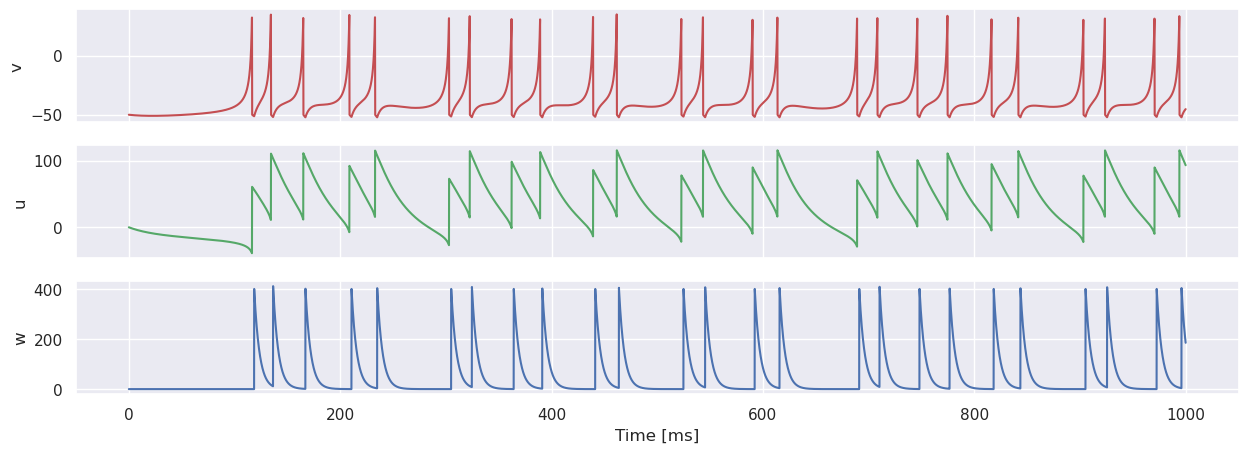

In [25]:
plot_membrane_variables(X, T)

{'peak_isi': np.float64(19.5), 'mean': np.float64(23.192307692307693), 'std': np.float64(4.267671232824676), 'count_sum': np.int64(13), 'prominence': np.float64(4.0)}
- - - -
24
0.16666666666666666
NUM PEAKS: [0]


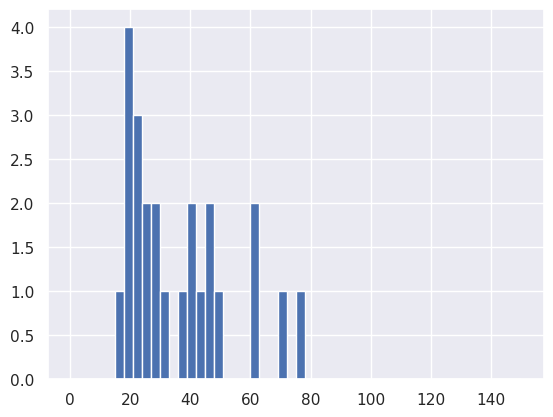

In [26]:

bins = 50
x_range = (0, 150)
counts, bin_edges = np.histogram(isi, bins = bins, range = x_range)
results = analyze_isi_peaks(counts, bin_edges, prominence = 0.15*np.sum(counts), distance = 1)

for res in results:
    print(res)
    print('- - - -')

print(np.sum(counts))
print(np.max(counts)/np.sum(counts))

print(f"NUM PEAKS: {get_num_peaks([spikes], bins, x_range, prominence_fraction = 0.2, distance = 1)}")

plt.hist(isi, bins = bins, range = x_range)
plt.show()
#plot_ISI_w_peaks(spikes, bins = bins, x_range = x_range)